# Running the snmachine pipeline on ELAsTiCC simulated data

This notebook illustrates the use of the `snmachine` supernova classification package by classifying a subset of the simulated training data from the Extended LSST Astronomical Time-series Classification Challenge (ELAsTiCC).

See Lochner et al. (2016): http://arxiv.org/abs/1603.00882 and Alves et al. (2021): https://arxiv.org/abs/2107.07531

**NOTE:** We use a small subset of the data in the interest of disk space and speed.

<img src="snmachine-plasticc.png" width=250>

This image illustrates the pipeline we use for this work. However, all the steps are modular and can be replaced. It is easy to write your own algorithm into the pipeline and change any of the steps.

## Setup

### Imports

In [67]:
import os

# If running on a laptop this will help prevent it from taking over your entire machine. If running on more serious compute, comment these out.
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['OPENBLAS_NUM_THREADS'] = '2'
os.environ['MKL_NUM_THREADS'] = '2'

In [68]:
import collections
import copy
import pickle

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [70]:
from snmachine import sndata, gps, snfeatures, snclassifier, analysis
from snmachine.utils.plasticc_pipeline import create_folder_structure, get_directories

In [71]:
%config Completer.use_jedi = False  # enable autocomplete

### Aesthetic settings

In [93]:
%matplotlib widget

sns.set(font_scale=1.3, style="ticks")

### Read from pickle or rerun
Because some calculations take a long time to run on a single core (mostly the Gaussian process fits), we recommend saving these objects as pickles and read from file after running once. This behaviour can be turned off with this flag.

In [73]:
read_from_pickle = True

## Set up output structure

We make lots of output files so it makes sense to put them in one place. This is the recommended output file structure.

We start by **naming** our analysis.

In [74]:
dataset_name = 'elasticc'
analysis_name = f'output_{dataset_name}'

Then, we **write** in `folder_path` the path where to save the folder.

In [77]:
# folder_path = '../snmachine/example_data/'
folder_path = "/home/michelle/BigData/SNClassification/snmachine/example_data/"

Create the folder structure.

In [78]:
create_folder_structure(folder_path, analysis_name)


                Folders already exist with this analysis name.

                Are you sure you would like to proceed, this will overwrite the
                output_elasticc folder [Y/n]
                
Overwriting existing folder..


See the folder structure. We save:
* the extracted features in `directories['features_directory']`
* the classification probabilities and ROC curves in `directories['classifications_directory']`
* the any intermediate files (such as multinest chains or GP fits) in `directories['intermediate_files_directory']`

In [79]:
directories = get_directories(folder_path, analysis_name) 
directories

{'analysis_directory': '/home/michelle/BigData/SNClassification/snmachine/example_data/output_elasticc',
 'features_directory': '/home/michelle/BigData/SNClassification/snmachine/example_data/output_elasticc/wavelet_features',
 'classifications_directory': '/home/michelle/BigData/SNClassification/snmachine/example_data/output_elasticc/classifications',
 'intermediate_files_directory': '/home/michelle/BigData/SNClassification/snmachine/example_data/output_elasticc/intermediate_files',
 'plots_directory': '/home/michelle/BigData/SNClassification/snmachine/example_data/output_elasticc/plots'}

In [80]:
path_saved_features = directories['features_directory']
path_saved_interm = directories['intermediate_files_directory']
path_saved_classifier = directories['classifications_directory']

## Initialise dataset object

Load the ELAsTiCC training data (hosted https://portal.nersc.gov/cfs/lsst/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2). For that, we download and extract `ELASTICC2_TRAIN_02.tar.bz2`, and **write** the path to the extracted folders.

In [81]:
data_path = '~/BigData/ELASTICC2'

For now we restrict ourselves to three supernova types: Ia, II and Ibc. ELAsTiCC simulates each type with several models, so we **write** in `class_map` the class of each model. To split the classes further, change their labels (e.g. `'SNIIn-MOSFIT': 'SNIIn'`).

In [82]:
class_map = {'SNIa-SALT3': 'SNIa',
             'SNIb-Templates': 'SNIbc', 'SNIb+HostXT_V19': 'SNIbc',
             'SNIc-Templates': 'SNIbc', 'SNIc+HostXT_V19': 'SNIbc',
             'SNIcBL+HostXT_V19': 'SNIbc',
             'SNII-Templates': 'SNII', 'SNII-NMF': 'SNII',
             'SNII+HostXT_V19': 'SNII', 'SNIIn-MOSFIT': 'SNII',
             'SNIIn+HostXT_V19': 'SNII', 'SNIIb+HostXT_V19': 'SNII'}

Each model is saved in 40 files. In the interest of time and memory, we only read one of them (`num_core_files`).

In [83]:
# This cell takes ~1min to run
dataset = sndata.ElasticcData(folder=data_path, src_classes=list(class_map),
                              class_map=class_map, num_core_files=1, quiet_load=True)

Reading data...
21026 objects read into memory.
This has taken 0 days 00:00:41



In [86]:
collections.Counter(dataset.labels)

Counter({'SNII': 10827, 'SNIbc': 5952, 'SNIa': 4247})

There is no separate test set, so we randomly choose a test set, and then a balanced training set with the same number of events from each class from the remaining events. **Choose** their sizes.

In [87]:
number_train_per_class = 3500
number_test = 1000

In [88]:
np.random.seed(42)
test_objs = np.random.choice(dataset.object_names, size=number_test, replace=False)

is_other = ~np.isin(dataset.object_names, test_objs)
other_objs = dataset.object_names[is_other]
other_labels = dataset.labels.values[is_other]
train_objs = np.concatenate([
    np.random.choice(other_objs[other_labels == label], size=number_train_per_class,
                     replace=False)
    for label in np.unique(other_labels)])
objs_to_keep = np.concatenate([train_objs, test_objs])

Update the dataset to only contain those SNe. Each light curve is processed independently, so we keep the training and test sets together until the dimensionality reduction of the features.

In [89]:
dataset.update_dataset(objs_to_keep)

Now we can plot all the data and cycle through it (left and right arrows on your keyboard).

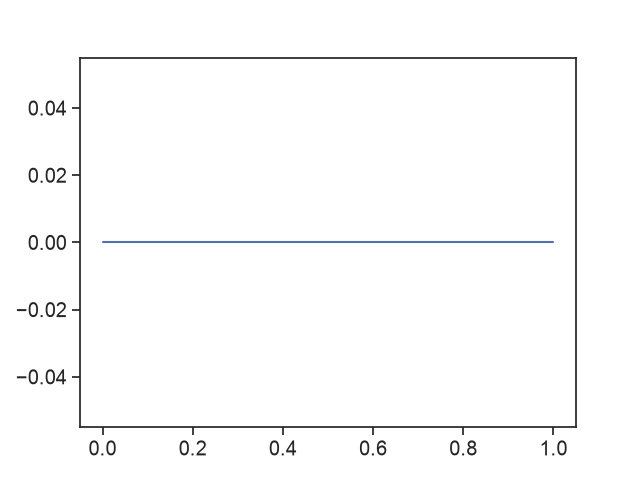

In [94]:
dataset.plot_all()

Each light curve is represented in the Dataset object as an astropy table, compatible with `sncosmo`:

In [95]:
dataset.data[dataset.object_names[0]]

object_id,mjd,filter,flux,flux_error,detected
str8,float64,str5,float32,float32,int64
29649164,0.0,lsstr,-5.319545,8.874424,0
29649164,0.011900000004970934,lssti,-2.4509678,16.708122,0
29649164,4.975800000000163,lsstz,-39.934055,23.504095,0
29649164,6.925699999999779,lssty,-74.22964,48.69683,0
29649164,6.948400000001129,lssty,-9.840164,39.562782,0
29649164,12.936099999998987,lssty,-124.028015,50.384933,0
29649164,12.936500000003434,lssty,8.639118,50.640495,0
29649164,12.960900000005495,lsstz,-38.17266,22.873009,0
29649164,12.96140000000014,lsstz,-9.341159,22.99009,0


## Preprocess dataset

**Write** the maximum duration of the gap to allowed in the light curves, `max_gap_length`.

In [96]:
max_gap_length = 50

To remove all the gaps longer than `max_gap_length`, the `remove_gaps` function must be called a few times; it only removes the first gap longer than `max_gap_length`.

To introduce uniformity in the dataset, the resulting light curves are translated so their first observation is at time zero.

In [97]:
dataset.remove_gaps(max_gap_length*2, verbose=True)
dataset.remove_gaps(max_gap_length*2, verbose=True)
dataset.remove_gaps(max_gap_length, verbose=True)
dataset.remove_gaps(max_gap_length, verbose=True)
dataset.remove_gaps(max_gap_length, verbose=True)

The longest event is 20062463 and its length is 1101.02 days.
The longest event is 35616030 and its length is 937.70 days.
The longest event is 68641701 and its length is 584.69 days.
The longest event is 64994850 and its length is 325.06 days.
The longest event is 1521192 and its length is 273.78 days.


Now we can see the light curves more clearly, focusing in on the season where the supernova actually occurred

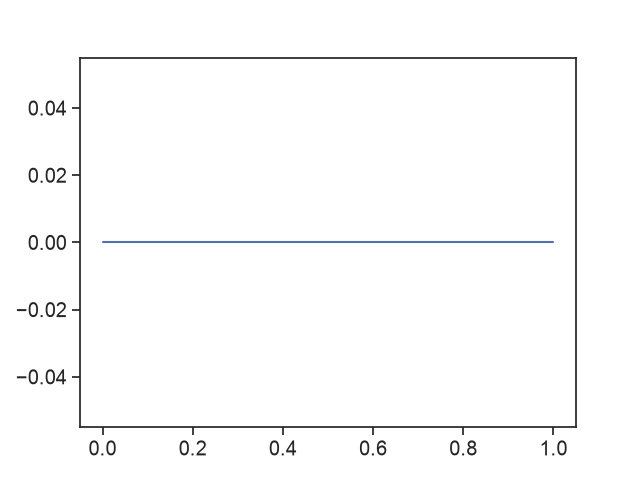

In [98]:
dataset.plot_all()

## Fit Gaussian Processes

Set the path to the folder to save the GP files.

In [99]:
path_saved_gps = directories['intermediate_files_directory']

**Choose**:
- `t_min`: minimim time to evaluate the Gaussian Process Regression at.
- `t_max`: maximum time to evaluate the Gaussian Process Regression at.
- `gp_dim`: dimension of the Gaussian Process Regression. If  `gp_dim` is 1, the filters are fitted independently. If `gp_dim` is 2, the Matern 3/2 kernel is used to fit light curves both in time and wavelength.
- `number_gp`: number of points to evaluate the Gaussian Process Regression at.
- `number_processes`: number of processors to use for parallelisation (**<font color=green>optional</font>**).

In [100]:
t_min = 0
t_max = 278

gp_dim = 2
number_gp = 276
number_processes = 1

In [101]:
dataset_pickle_name = os.path.join(folder_path, 'elasticc_dataset.pckl')
if read_from_pickle and os.path.exists(dataset_pickle_name):
    with open(dataset_pickle_name, 'rb') as pickle_file:
        dataset = pickle.load(pickle_file)
        print('Dataset read in from', dataset_pickle_name)
else:
    # This cell can take a few minutes
    gps.compute_gps(dataset, number_gp=number_gp, t_min=t_min, t_max=t_max,
                    gp_dim=gp_dim, output_root=path_saved_gps,
                    number_processes=number_processes)

    with open(dataset_pickle_name, 'wb') as pickle_file:
        pickle.dump(dataset, pickle_file)

Dataset read in from /home/michelle/BigData/SNClassification/snmachine/example_data/elasticc_dataset.pckl


At the moment no other parameters are tunable for 2D Gaussian processes. For more details on this modeling of the light curves, see section _3.2. Gaussian Process Modeling of Light Curves_ of the [paper]().

Now we can see how our light curves look with GP models.

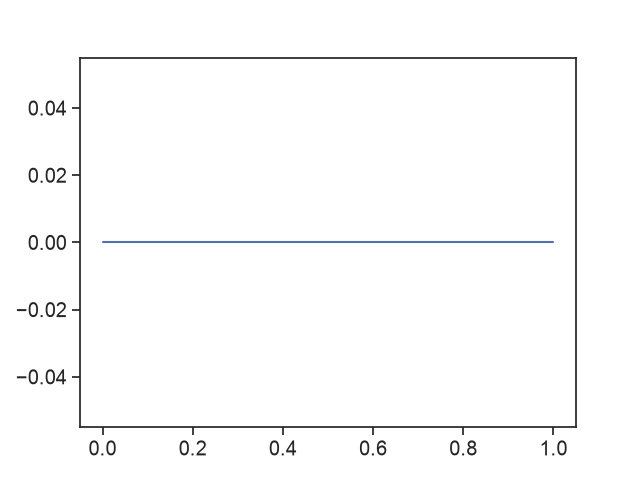

In [102]:
dataset.plot_all(plot_model=True)

## Augment Dataset

In PLAsTiCC the training set is not representative of the test set, so we augment it (see `example_plasticc.ipynb`). Here the training and test sets are random subsets of the same simulation, so we skip this step. The augmentation classes in `snaugment` were also tuned to PLAsTiCC-like simulations and do not reproduce ELAsTiCC light curves.

## Extract features for the data

The next step is to extract useful features from the data. This can often take a long time, depending on the feature extraction method, so it's a good idea to save these to file.

### Wavelet Decomposition<a name="waveletDecomp"></a>

Now, we do a wavelet decomposition of the events. **Write** in `path_saved_wavelets` the path to the folder where to save them.

In [103]:
path_saved_wavelets = directories['intermediate_files_directory']

In [104]:
wf = snfeatures.WaveletFeatures(output_root=path_saved_wavelets)

wf.compute_wavelet_decomp(dataset, wavelet_name='sym2', number_decomp_levels=2)

The wavelet used is sym2.
Each passband is decomposed in 2 levels.
Performing wavelet decomposition.
Time taken for wavelet decomposition: 19.26s.


### Dimensionality Reduction

Following [Lochner et al. (2016)](https://iopscience.iop.org/article/10.3847/0067-0049/225/2/31), we then reduced the dimensionality of this wavelet space using Principal Component Analysis (PCA). Therefore, **choose** the number of PCA components to keep (`number_comps`) and **write** the path to the folder where to save the eigendecomposition (`path_saved_reduced_wavelets`).

In [105]:
number_comps = 40
path_saved_reduced_wavelets = directories['features_directory']

To avoid using any information from the test set, the eigendecomposition is computed using only the training set events.

In [106]:
train_data = copy.deepcopy(dataset)
train_data.update_dataset(train_objs)

wf.compute_eigendecomp(train_data, path_save_eigendecomp=path_saved_reduced_wavelets)

Performing eigendecomposition.
Time taken for eigendecomposition: 120.95s.


Then, all the events are projected onto the principal components of the training set.

In [108]:
feature_space = wf.load_feature_space(dataset)
reduced_wavelet_features = wf.project_to_space(feature_space, path_saved_reduced_wavelets, number_comps=number_comps)

Dimensionality reduced feature space with 40 components.


Save the reduced features.

In [109]:
wf.save_reduced_features(reduced_wavelet_features, path_saved_reduced_wavelets)

Include Redshift Information<a name="addZ"></a>

In [paper]() we found that photometric redshift and its uncertainty are crucial for classification. Therefore, in the cell bellow, we include these properties as features. **Modify** it to include other properties as features.

In [110]:
features = reduced_wavelet_features.copy()  # only the wavelet features

metadata = dataset.metadata
features['hostgal_photoz'] = metadata.hostgal_photoz.values.astype(float)
features['hostgal_photoz_err'] = metadata.hostgal_photoz_err.values.astype(float)

### Split into training and test sets

In [111]:
train_features = features.loc[train_objs]
test_features = features.loc[test_objs]

train_data_labels = metadata.target.loc[train_objs].astype(str)  # class label of each event
test_data_labels = metadata.target.loc[test_objs].astype(str)

To save the features, **write** in `saved_features_path` the path to the folder where to save them.

In [112]:
path_saved_features = directories['features_directory']

In [113]:
train_features.to_pickle(os.path.join(path_saved_features, 'train_features.pckl'))
train_data_labels.to_pickle(os.path.join(path_saved_features, 'train_data_labels.pckl'))
test_features.to_pickle(os.path.join(path_saved_features, 'test_features.pckl'))
test_data_labels.to_pickle(os.path.join(path_saved_features, 'test_data_labels.pckl'))

## Classify

Finally, we're ready to run the machine learning algorithm. There's a utility function in the `snclassifier` library to make it easy to run all the algorithms available, including converting features to `numpy` arrays and rescaling them and automatically generating ROC curves and metrics. Hyperparameters are automatically selected using a grid search combined with cross-validation. All functionality can also be individually run from `snclassifier`.

Here we chose a LightGBM classifier.

In [114]:
classifier_instance = snclassifier.LightGBMClassifier(classifier_name='LGBM', random_seed=42, verbose=-1)

Created classifier of type: LGBMClassifier(random_state=42, verbose=-1).



We can now train and use the classifier generated above or optimise it beforehand. In general, it is important to optimise the classifier hyperparameters.

In the paper we use the default optimisation but in interest of time, we do here a shorter optimisation.

**Choose** the metric to optimise: the ELAsTiCC logloss (`'elasticc_logloss'`) or the AUC of the class given in `true_class` (`'auc'`). No official ELAsTiCC metric was published, so the ELAsTiCC logloss is the PLAsTiCC weighted logloss with the same weight for the classes that are not in PLAsTiCC.

In [115]:
scoring = 'elasticc_logloss'  # or 'auc'
true_class = 'SNIa'  # only used if scoring='auc'

In [116]:
param_grid={'learning_rate': [.1, .25, .5]}

classifier_instance.optimise(train_features, train_data_labels,       param_grid=param_grid, scoring=scoring, true_class=true_class,
                             number_cv_folds=5, metadata=metadata.loc[train_objs])

The optimisation takes 16.199s.


### Test set

#### Classify Test Set

Compute the predicted class (`y_pred`) and the probability of belonging to each different class (`y_probs`). Note that the predicted class is the one with the highest probability.

In [117]:
classifier = classifier_instance.classifier
y_pred_test = classifier.predict(test_features)
y_probs_test = classifier.predict_proba(test_features)

#### Performance

If we know the true class label of each event we can calculate the performance of the classifier. Otherwise, our predictions are saved in `y_pred_test` and `y_probs_test`.

In this example we know the true class labels.

We start by computing the Area under the ROC Curve (AUC) and the ELAsTiCC logloss. For that, choose which class to consider as *positive* (the other classes will be considered *negative*). Then, **write** in `which_column` the column that corresponds to that class. Note that the class order is accessed through the classifier.

In [118]:
which_column = list(classifier.classes_).index('SNIa')  # we are interested in SN Ia vs others

In [119]:
classifier.which_column = which_column
auc_test = snclassifier.auc_score(classifier=classifier, X_features=test_features,
                                  y_true=test_data_labels, which_column=which_column)
logloss_test = snclassifier.elasticc_logloss_score(classifier=classifier, X_features=test_features,
                                                   y_true=test_data_labels)
print('{:^10} {:^10} {:^10}'.format('', 'AUC', 'Logloss'))
print('{:^10} {:^10.3f} {:^10.3f}'.format('test', auc_test, logloss_test))

              AUC      Logloss  
   test      0.881      -0.771  


Now, we plot the confusion matrix.

Confusion matrix normalised by true class.


array([[0.66728972, 0.14018692, 0.19252336],
       [0.13567839, 0.74874372, 0.11557789],
       [0.19548872, 0.16165414, 0.64285714]])

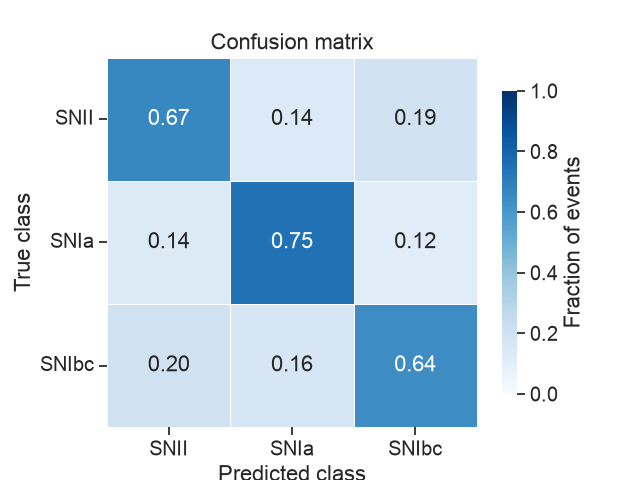

In [120]:
title = 'Confusion matrix'
analysis.plot_confusion_matrix(test_data_labels, y_pred_test, normalise='accuracy', title=title)

ROC Curves

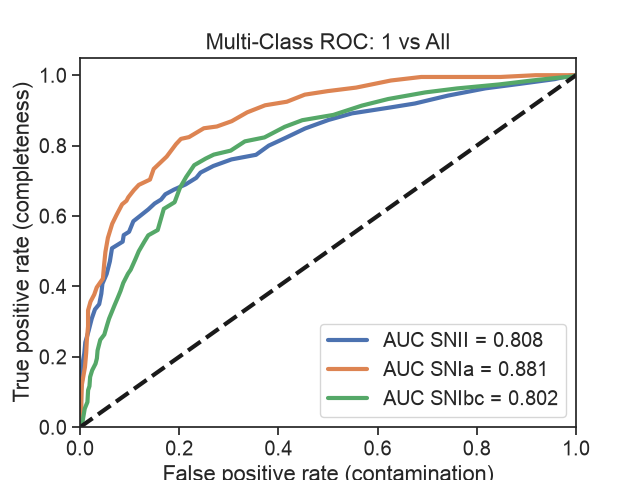

In [122]:
analysis.plot_classifier_roc_curve(test_data_labels, y_probs_test)

And that's it! An end-to-end analysis on the ELAsTiCC dataset.